# Experiment No. 05
## Polynomial Regression, Overfitting, Ridge and Lasso Regularisation

## Aim

To study polynomial regression and the effect of increasing model complexity on training and testing errors, identify overfitting, and apply Ridge and Lasso regularisation to control model complexity and reduce overfitting.

## Objectives

After completing this experiment, students will be able to:

1. Understand the concept of polynomial regression.
2. Investigate how polynomial degree affects model complexity.
3. Compare training MSE and testing MSE for different polynomial degrees.
4. Identify the point at which a model begins to overfit.
5. Understand the difference between underfitting and overfitting.
6. Apply Ridge (L2) regularisation to a high-degree polynomial model.
7. Apply Lasso (L1) regularisation to a high-degree polynomial model.
8. Study how Ridge shrinks model coefficients.
9. Study how Lasso can force some coefficients to exactly zero.
10. Select a suitable polynomial degree and regularisation method based on test performance.

## Theory

### Polynomial Regression

Polynomial Regression is an extension of Linear Regression that models the relationship between the input variable and target variable using polynomial terms.

For example, a polynomial model of degree 3 can be represented as:

$$
y = b_0 + b_1x + b_2x^2 + b_3x^3
$$

Increasing the polynomial degree allows the model to capture more complex relationships in the data.

### Underfitting

Underfitting occurs when the model is too simple to capture the underlying relationship in the data.

A typical sign of underfitting is:

- High training error
- High testing error

### Overfitting

Overfitting occurs when the model becomes too complex and starts learning noise and random variations in the training data.

A typical sign of overfitting is:

- Very low training error
- Relatively high testing error

The difference between training and testing error is called the **generalisation gap**.

$$
Generalisation\ Gap = Testing\ MSE - Training\ MSE
$$

### Ridge Regression

Ridge Regression uses **L2 regularisation** to penalise large coefficients.

The objective function is:

$$
Loss = MSE + \alpha \sum_{j=1}^{n} \beta_j^2
$$

A larger value of $\alpha$ produces stronger regularisation and generally shrinks coefficients more strongly toward zero.

### Lasso Regression

Lasso Regression uses **L1 regularisation**.

Its objective function is:

$$
Loss = MSE + \alpha \sum_{j=1}^{n} |\beta_j|
$$

Unlike Ridge, Lasso can force some coefficients exactly to zero. Therefore, Lasso can also perform feature selection.

### Mean Squared Error

Mean Squared Error (MSE) measures the average squared difference between actual and predicted values.

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y_i})^2
$$

A lower MSE indicates better predictive performance.

## Pseudo Algorithm

### Input

Housing Prices Dataset:
https://www.kaggle.com/datasets/yasserh/housing-prices-dataset

### Steps

1. Start.
2. Load the house-pricing dataset.
3. Select one numerical predictor and the target variable.
4. Divide the data into training and testing sets.
5. Predict how train and test errors will change as polynomial degree increases.
6. Create polynomial features for degrees 1, 3 and 10.
7. Train a Linear Regression model for each degree.
8. Calculate training MSE and testing MSE.
9. Store the results in a table.
10. Plot training and testing MSE against polynomial degree.
11. Identify the degree at which the model begins to overfit.
12. Select the high-degree polynomial model as the overfit model.
13. Apply Ridge regularisation using different values of alpha.
14. Apply Lasso regularisation using the same or comparable values of alpha.
15. Calculate test MSE for each regularised model.
16. Examine the magnitude of Ridge coefficients.
17. Count the number of zero coefficients produced by Lasso.
18. Compare unregularised, Ridge and Lasso models.
19. Try an intermediate polynomial degree such as 3 or 5 with regularisation.
20. Select the final model based primarily on test performance and model simplicity.
21. Write the final conclusion.
22. Stop.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error

In [4]:
df = pd.read_csv("datasets/housing.csv")

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (5000, 7)

First 5 Rows:


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05,USNS Raymond\nFPO AE 09386


In [5]:
print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
display(df.describe())

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   str    
dtypes: float64(6), str(1)
memory usage: 273.6 KB

Missing Values:
Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

Statistical Summary:


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562390,5.322283,6.299250,3.140000,29403.928700,9.975771e+05
50%,68804.286405,5.970429,7.002902,4.050000,36199.406690,1.232669e+06
75%,75783.338665,6.650808,7.665871,4.490000,42861.290770,1.471210e+06
max,107701.748400,9.519088,10.759588,6.500000,69621.713380,2.469066e+06


In [8]:
X = df[["Area Population"]]
y = df["Price"]

print("Feature:")
display(X.head())

print("\nTarget:")
display(y.head())

Feature:


,Area Population
0,23086.80050
1,40173.07217
2,36882.15940
3,34310.24283
4,26354.10947



Target:


0    1.059034e+06
1    1.505891e+06
2    1.058988e+06
3    1.260617e+06
4    6.309435e+05
Name: Price, dtype: float64

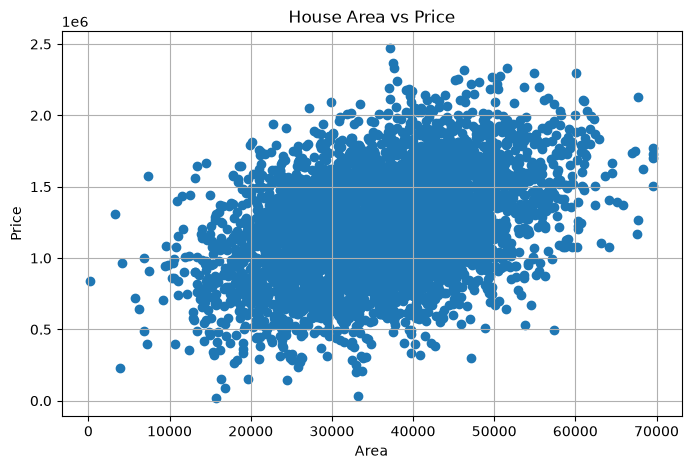

In [9]:
plt.figure(figsize=(8, 5))

plt.scatter(X, y)

plt.xlabel("Area")
plt.ylabel("Price")
plt.title("House Area vs Price")

plt.grid(True)
plt.show()

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 4000
Testing Samples: 1000


In [11]:
degrees = [1, 3, 10]

results = []

models = {}

for degree in degrees:

    poly = PolynomialFeatures(
        degree=degree,
        include_bias=False
    )

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()

    model.fit(
        X_train_poly,
        y_train
    )

    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    train_mse = mean_squared_error(
        y_train,
        y_train_pred
    )

    test_mse = mean_squared_error(
        y_test,
        y_test_pred
    )

    results.append([
        degree,
        train_mse,
        test_mse
    ])

    models[degree] = {
        "poly": poly,
        "model": model
    }

results_df = pd.DataFrame(
    results,
    columns=[
        "Degree",
        "Training MSE",
        "Testing MSE"
    ]
)

results_df

,Degree,Training MSE,Testing MSE
0,1,1.043559e+11,1.018846e+11
1,3,1.043553e+11,1.020829e+11
2,10,1.119907e+11,1.111745e+11


In [12]:
display(
    results_df.round(2)
)

,Degree,Training MSE,Testing MSE
0,1,1.043559e+11,1.018846e+11
1,3,1.043553e+11,1.020829e+11
2,10,1.119907e+11,1.111745e+11


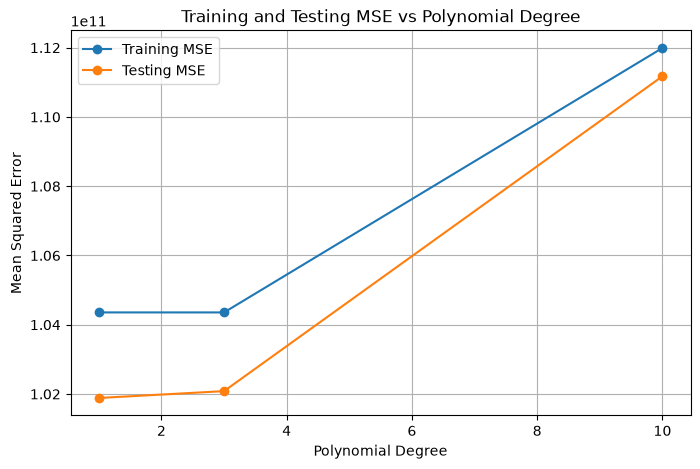

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Degree"],
    results_df["Training MSE"],
    marker="o",
    label="Training MSE"
)

plt.plot(
    results_df["Degree"],
    results_df["Testing MSE"],
    marker="o",
    label="Testing MSE"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Training and Testing MSE vs Polynomial Degree")

plt.legend()
plt.grid(True)

plt.show()

/opt/miniconda3/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


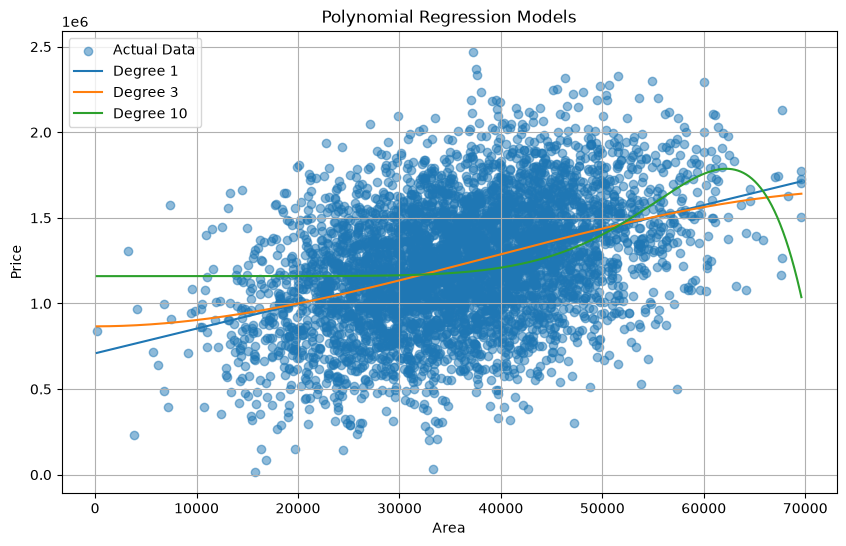

In [14]:
X_plot = np.linspace(
    X.min().iloc[0],
    X.max().iloc[0],
    500
).reshape(-1, 1)

plt.figure(figsize=(10, 6))

plt.scatter(
    X,
    y,
    alpha=0.5,
    label="Actual Data"
)

for degree in degrees:

    poly = models[degree]["poly"]
    model = models[degree]["model"]

    X_plot_poly = poly.transform(X_plot)

    y_plot = model.predict(
        X_plot_poly
    )

    plt.plot(
        X_plot,
        y_plot,
        label=f"Degree {degree}"
    )

plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Polynomial Regression Models")

plt.legend()
plt.grid(True)

plt.show()

In [15]:
results_df["Generalisation Gap"] = (
    results_df["Testing MSE"]
    - results_df["Training MSE"]
)

display(
    results_df.round(2)
)

,Degree,Training MSE,Testing MSE,Generalisation Gap
0,1,1.043559e+11,1.018846e+11,-2.471266e+09
1,3,1.043553e+11,1.020829e+11,-2.272409e+09
2,10,1.119907e+11,1.111745e+11,-8.161789e+08


In [16]:
degree = 10

poly = PolynomialFeatures(
    degree=degree,
    include_bias=False
)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

alphas = [0.01, 0.1, 1, 10, 100]

ridge_results = []

ridge_models = {}

for alpha in alphas:

    ridge = Ridge(
        alpha=alpha
    )

    ridge.fit(
        X_train_poly,
        y_train
    )

    y_test_pred = ridge.predict(
        X_test_poly
    )

    test_mse = mean_squared_error(
        y_test,
        y_test_pred
    )

    ridge_results.append([
        alpha,
        test_mse
    ])

    ridge_models[alpha] = ridge

ridge_df = pd.DataFrame(
    ridge_results,
    columns=[
        "Alpha",
        "Testing MSE"
    ]
)

display(
    ridge_df.round(2)
)

/opt/miniconda3/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.0691282949371854e-92.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/miniconda3/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.0691281420645113e-92.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/miniconda3/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.070080899014182e-92.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/miniconda3/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.0673731044375113e-92.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/miniconda3/lib/python3.14/site-p

,Alpha,Testing MSE
0,0.01,1.018207e+11
1,0.10,1.018207e+11
2,1.00,1.018207e+11
3,10.00,1.018205e+11
4,100.00,1.018207e+11


In [17]:
linear_model = models[10]["model"]

coefficient_comparison = pd.DataFrame({
    "Polynomial Term": [
        f"x^{i}"
        for i in range(1, 11)
    ],
    "Unregularised": linear_model.coef_,
    "Ridge Alpha=1": ridge_models[1].coef_
})

display(
    coefficient_comparison.round(4)
)

,Polynomial Term,Unregularised,Ridge Alpha=1
0,x^1,0.0,-2.8467
1,x^2,0.0,0.0066
2,x^3,0.0,-0.0000
3,x^4,0.0,0.0000
4,x^5,0.0,-0.0000
5,x^6,0.0,0.0000
6,x^7,0.0,-0.0000
7,x^8,0.0,0.0000
8,x^9,0.0,-0.0000
9,x^10,-0.0,0.0000


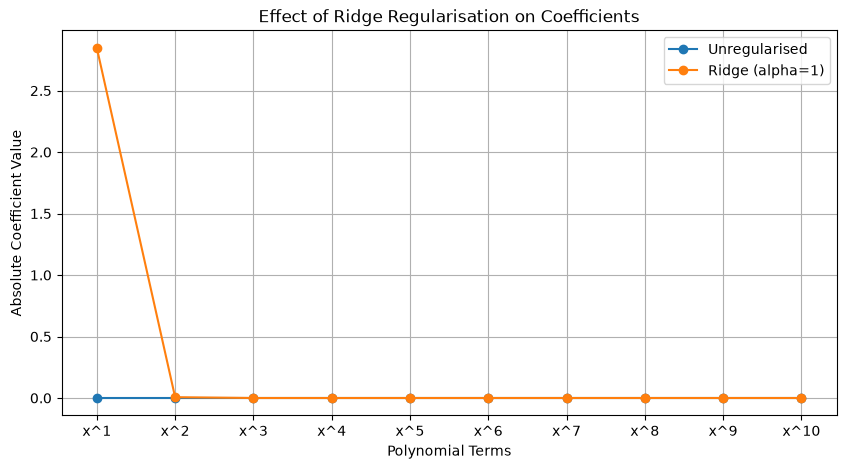

In [18]:
terms = [
    f"x^{i}"
    for i in range(1, 11)
]

plt.figure(figsize=(10, 5))

plt.plot(
    terms,
    np.abs(linear_model.coef_),
    marker="o",
    label="Unregularised"
)

plt.plot(
    terms,
    np.abs(ridge_models[1].coef_),
    marker="o",
    label="Ridge (alpha=1)"
)

plt.xlabel("Polynomial Terms")
plt.ylabel("Absolute Coefficient Value")
plt.title("Effect of Ridge Regularisation on Coefficients")

plt.legend()
plt.grid(True)

plt.show()

In [19]:
lasso_results = []

lasso_models = {}

for alpha in alphas:

    lasso = Lasso(
        alpha=alpha,
        max_iter=100000
    )

    lasso.fit(
        X_train_poly,
        y_train
    )

    y_test_pred = lasso.predict(
        X_test_poly
    )

    test_mse = mean_squared_error(
        y_test,
        y_test_pred
    )

    zero_coefficients = np.sum(
        np.isclose(
            lasso.coef_,
            0
        )
    )

    lasso_results.append([
        alpha,
        test_mse,
        zero_coefficients
    ])

    lasso_models[alpha] = lasso

lasso_df = pd.DataFrame(
    lasso_results,
    columns=[
        "Alpha",
        "Testing MSE",
        "Number of Zero Coefficients"
    ]
)

display(
    lasso_df.round(2)
)

/opt/miniconda3/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.086646e+14, tolerance: 5.002e+10
  model = cd_fast.enet_coordinate_descent(
/opt/miniconda3/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.086646e+14, tolerance: 5.002e+10
  model = cd_fast.enet_coordinate_descent(
/opt/miniconda3/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.08664

,Alpha,Testing MSE,Number of Zero Coefficients
0,0.01,1.019669e+11,8
1,0.10,1.019669e+11,8
2,1.00,1.019669e+11,8
3,10.00,1.019669e+11,8
4,100.00,1.019669e+11,8


In [20]:
lasso_alpha = 1

lasso_coefficient_df = pd.DataFrame({
    "Polynomial Term": terms,
    "Lasso Coefficient": lasso_models[lasso_alpha].coef_
})

display(
    lasso_coefficient_df.round(4)
)

zero_count = np.sum(
    np.isclose(
        lasso_models[lasso_alpha].coef_,
        0
    )
)

print(
    "Number of zero coefficients:",
    zero_count
)

,Polynomial Term,Lasso Coefficient
0,x^1,3.9192
1,x^2,0.0005
2,x^3,-0.0000
3,x^4,0.0000
4,x^5,0.0000
5,x^6,0.0000
6,x^7,-0.0000
7,x^8,-0.0000
8,x^9,-0.0000
9,x^10,0.0000


Number of zero coefficients: 8


In [21]:
unregularised_mse = results_df.loc[
    results_df["Degree"] == 10,
    "Testing MSE"
].iloc[0]

best_ridge = ridge_df.loc[
    ridge_df["Testing MSE"].idxmin()
]

best_lasso = lasso_df.loc[
    lasso_df["Testing MSE"].idxmin()
]

comparison_df = pd.DataFrame({
    "Model": [
        "Polynomial Degree 10",
        "Best Ridge",
        "Best Lasso"
    ],
    "Alpha": [
        0,
        best_ridge["Alpha"],
        best_lasso["Alpha"]
    ],
    "Testing MSE": [
        unregularised_mse,
        best_ridge["Testing MSE"],
        best_lasso["Testing MSE"]
    ]
})

display(
    comparison_df.round(2)
)

,Model,Alpha,Testing MSE
0,Polynomial Degree 10,0.0,1.111745e+11
1,Best Ridge,10.0,1.018205e+11
2,Best Lasso,100.0,1.019669e+11


In [22]:
degree = 3

poly_3 = PolynomialFeatures(
    degree=degree,
    include_bias=False
)

X_train_poly_3 = poly_3.fit_transform(X_train)
X_test_poly_3 = poly_3.transform(X_test)

ridge_3 = Ridge(alpha=1)
lasso_3 = Lasso(
    alpha=1,
    max_iter=100000
)

ridge_3.fit(
    X_train_poly_3,
    y_train
)

lasso_3.fit(
    X_train_poly_3,
    y_train
)

ridge_3_pred = ridge_3.predict(
    X_test_poly_3
)

lasso_3_pred = lasso_3.predict(
    X_test_poly_3
)

ridge_3_mse = mean_squared_error(
    y_test,
    ridge_3_pred
)

lasso_3_mse = mean_squared_error(
    y_test,
    lasso_3_pred
)

print(
    "Degree 3 Ridge Test MSE:",
    round(ridge_3_mse, 2)
)

print(
    "Degree 3 Lasso Test MSE:",
    round(lasso_3_mse, 2)
)

/opt/miniconda3/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.816113805767673e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Degree 3 Ridge Test MSE: 101969724599.03
Degree 3 Lasso Test MSE: 101969724636.52


/opt/miniconda3/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.192195e+14, tolerance: 5.002e+10
  model = cd_fast.enet_coordinate_descent(


In [23]:
all_models = []

for _, row in results_df.iterrows():

    all_models.append({
        "Model": f"Polynomial Degree {int(row['Degree'])}",
        "Testing MSE": row["Testing MSE"]
    })

for _, row in ridge_df.iterrows():

    all_models.append({
        "Model": f"Ridge Degree 10 (alpha={row['Alpha']})",
        "Testing MSE": row["Testing MSE"]
    })

for _, row in lasso_df.iterrows():

    all_models.append({
        "Model": f"Lasso Degree 10 (alpha={row['Alpha']})",
        "Testing MSE": row["Testing MSE"]
    })

all_models.extend([
    {
        "Model": "Ridge Degree 3 (alpha=1)",
        "Testing MSE": ridge_3_mse
    },
    {
        "Model": "Lasso Degree 3 (alpha=1)",
        "Testing MSE": lasso_3_mse
    }
])

all_models_df = pd.DataFrame(
    all_models
)

all_models_df = all_models_df.sort_values(
    "Testing MSE"
).reset_index(drop=True)

display(
    all_models_df.round(2)
)

print(
    "\nBest Model:",
    all_models_df.iloc[0]["Model"]
)

print(
    "Best Testing MSE:",
    round(
        all_models_df.iloc[0]["Testing MSE"],
        2
    )
)

,Model,Testing MSE
0,Ridge Degree 10 (alpha=10.0),1.018205e+11
1,Ridge Degree 10 (alpha=0.1),1.018207e+11
2,Ridge Degree 10 (alpha=0.01),1.018207e+11
3,Ridge Degree 10 (alpha=100.0),1.018207e+11
4,Ridge Degree 10 (alpha=1.0),1.018207e+11
5,Polynomial Degree 1,1.018846e+11
6,Lasso Degree 10 (alpha=100.0),1.019669e+11
7,Lasso Degree 10 (alpha=10.0),1.019669e+11
8,Lasso Degree 10 (alpha=1.0),1.019669e+11
9,Lasso Degree 10 (alpha=0.1),1.019669e+11



Best Model: Ridge Degree 10 (alpha=10.0)
Best Testing MSE: 101820529748.83


## Observation

1. Polynomial Regression models were successfully trained for degrees 1, 3, and 10.
2. The degree-1 model represents a simple linear relationship between house area and price.
3. Increasing the polynomial degree increases model complexity.
4. Training MSE generally decreases as model complexity increases.
5. Testing MSE initially improves as the model captures more useful patterns.
6. At sufficiently high complexity, the testing error may increase while training error continues to decrease, indicating overfitting.
7. A large difference between training and testing MSE indicates a large generalisation gap.
8. Ridge Regression was applied to the high-degree polynomial model using different values of alpha.
9. Ridge regularisation reduced the magnitude of the polynomial coefficients.
10. Lasso Regression was also applied to the high-degree polynomial model.
11. Lasso was able to shrink some polynomial coefficients exactly to zero.
12. Different values of alpha produced different levels of regularisation.
13. Regularisation can improve the generalisation of a high-degree polynomial model.
14. The final model should be selected using testing or validation performance while also considering model simplicity.

## Observation

1. Polynomial Regression models were successfully trained for degrees 1, 3, and 10.
2. The degree-1 model represents a simple linear relationship between house area and price.
3. Increasing the polynomial degree increases model complexity.
4. Training MSE generally decreases as model complexity increases.
5. Testing MSE initially improves as the model captures more useful patterns.
6. At sufficiently high complexity, the testing error may increase while training error continues to decrease, indicating overfitting.
7. A large difference between training and testing MSE indicates a large generalisation gap.
8. Ridge Regression was applied to the high-degree polynomial model using different values of alpha.
9. Ridge regularisation reduced the magnitude of the polynomial coefficients.
10. Lasso Regression was also applied to the high-degree polynomial model.
11. Lasso was able to shrink some polynomial coefficients exactly to zero.
12. Different values of alpha produced different levels of regularisation.
13. Regularisation can improve the generalisation of a high-degree polynomial model.
14. The final model should be selected using testing or validation performance while also considering model simplicity.

## Result

Polynomial Regression was successfully implemented using polynomial degrees 1, 3, and 10.

The effect of polynomial degree on training and testing MSE was studied. Increasing model complexity reduced training error, while excessive complexity could result in a large generalisation gap and overfitting.

Ridge and Lasso regularisation were successfully applied to the high-degree polynomial model. Ridge reduced the magnitude of model coefficients, while Lasso was able to force some coefficients to exactly zero.

The models were compared using testing MSE, and the final model was selected based primarily on its test performance and model simplicity.

## Conclusion

The experiment demonstrated that increasing polynomial degree increases model complexity. A low-degree polynomial may underfit the data, while a very high-degree polynomial may overfit the training data.

Ridge and Lasso regularisation provide methods for controlling model complexity. Ridge shrinks coefficients toward zero, whereas Lasso can reduce some coefficients exactly to zero.

Therefore, the best model is not necessarily the most complex model. A suitable polynomial degree combined with appropriate regularisation can provide better generalisation to unseen data.